# **Project Name**    - Blood Donation Prediction







##### **Project Type**    - Classification
##### **Contribution**    - Individual
##### **Team Member 1** -Mahesh A

# **Project Summary -**

Blood donation plays a vital role in healthcare, but predicting donor behavior is challenging due to limited data and imbalanced records. The Blood Donation Prediction project aims to build a machine learning system that can automatically identify whether a donor is likely to give blood again, based on historical donation patterns.

The dataset contains donor records with features such as Months since Last Donation (Recency), Number of Donations (Frequency), Total Volume Donated (c.c.), and Months since First Donation (Tenure). The target variable indicates whether the donor made a donation in March 2007.

Data analysis was performed to examine feature distributions, class imbalance, and correlations. Preprocessing steps included handling missing values, scaling numeric features, and splitting the dataset into training and testing sets. To address the imbalance in donor vs. non‑donor classes, SMOTE oversampling was applied.

Several models were developed and compared:

Logistic Regression as a baseline.

Random Forest, Gradient Boosting, and XGBoost as ensemble methods to capture non‑linear relationships.

Hyperparameter tuning using RandomizedSearchCV to optimize performance.

Evaluation metrics such as accuracy, precision, recall, F1‑score, and ROC‑AUC were used to assess model effectiveness. Results showed that the tuned Random Forest achieved the best balance of metrics, making it the recommended choice for deployment.

# **GitHub Link -**

# **Problem Statement**


Task 1:-Prepare a complete data analysis report on the given data.

Task 2:-Create a predictive model which will help to repeat blood donations amongst donors based on a limited number of attributes


# ***Let's Begin !***

### Import Libraries

In [10]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE


Explanation:  

 We begin by importing all the necessary libraries for data handling, visualization, and modeling. Pandas and NumPy manage tabular and numerical data, Matplotlib and Seaborn create plots, scikit‑learn provides machine learning tools, and SMOTE from imbalanced‑learn helps balance the dataset.

### Load Dataset

In [11]:
# Load dataset
df = pd.read_csv('/content/Warm_Up_Predict_Blood_Donations_-_Traning_Data.csv')
print("Shape:", df.shape)
print(df.isnull().sum())
df.head()


Shape: (576, 6)
Unnamed: 0                     0
Months since Last Donation     0
Number of Donations            0
Total Volume Donated (c.c.)    0
Months since First Donation    0
Made Donation in March 2007    0
dtype: int64


,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,619,2,50,12500,98,1
1,664,0,13,3250,28,1
2,441,1,16,4000,35,1
3,160,2,20,5000,45,1
4,358,1,24,6000,77,0


Explanation:  

 The dataset is loaded into a Pandas DataFrame using read_csv. We check its shape to see the number of rows and columns, inspect for missing values, and preview the first few records to understand the structure and features available.

### Exploratory Data Analysis (EDA)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Unnamed: 0                   576 non-null    int64
 1   Months since Last Donation   576 non-null    int64
 2   Number of Donations          576 non-null    int64
 3   Total Volume Donated (c.c.)  576 non-null    int64
 4   Months since First Donation  576 non-null    int64
 5   Made Donation in March 2007  576 non-null    int64
dtypes: int64(6)
memory usage: 27.1 KB
None
       Unnamed: 0  Months since Last Donation  Number of Donations  \
count  576.000000                  576.000000           576.000000   
mean   374.034722                    9.439236             5.427083   
std    216.947773                    8.175454             5.740010   
min      0.000000                    0.000000             1.000000   
25%    183.750000                    2.000000         

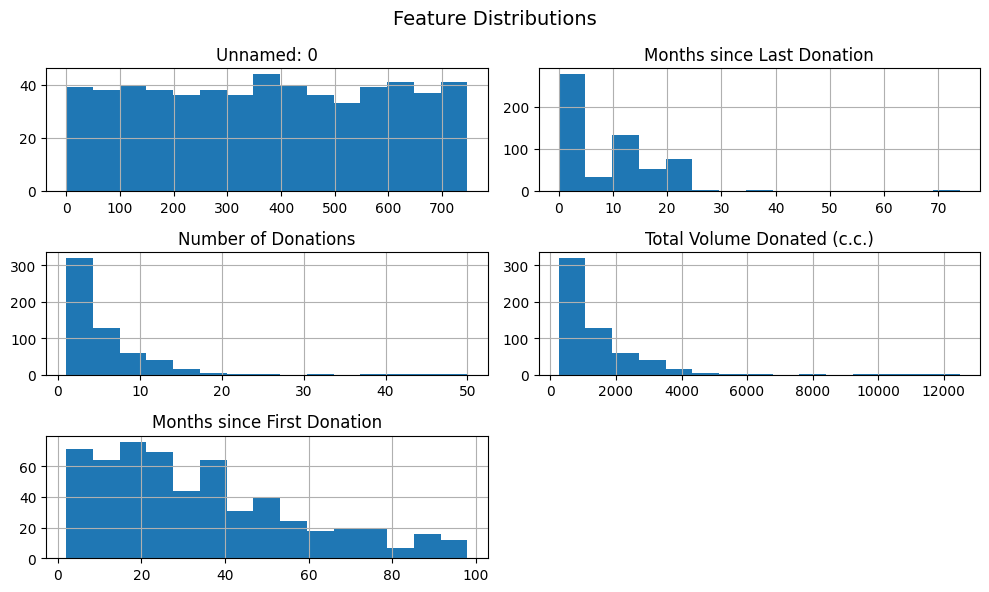

Target Counts:
 Made Donation in March 2007
0    438
1    138
Name: count, dtype: int64
Target Percentages:
 Made Donation in March 2007
0    76.04
1    23.96
Name: proportion, dtype: float64


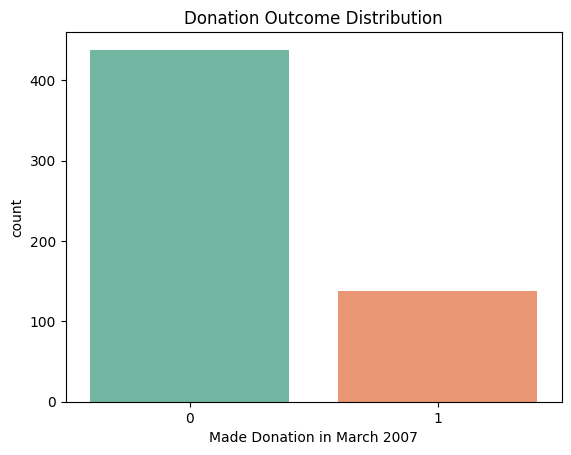

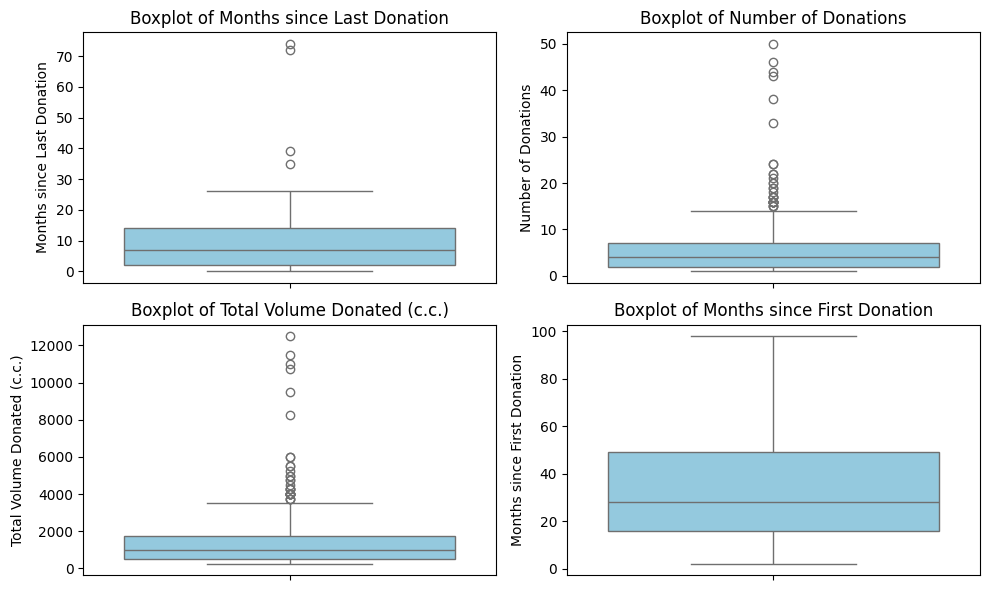

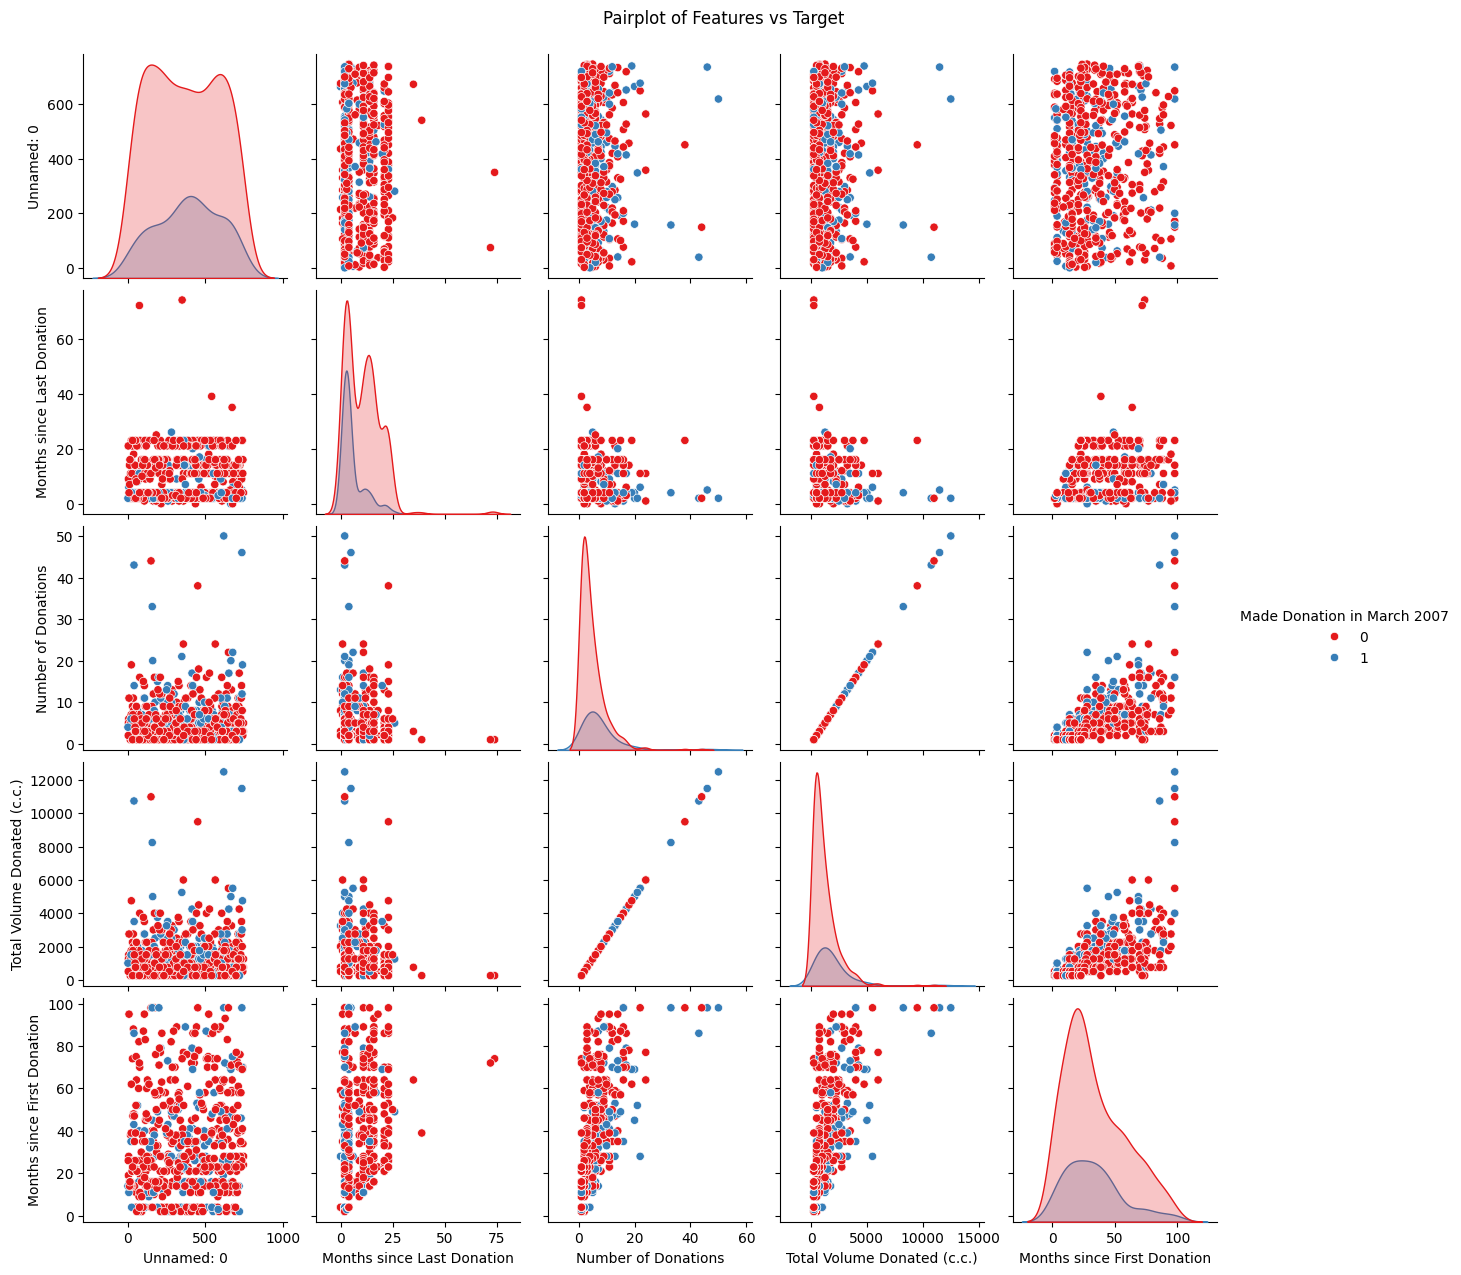

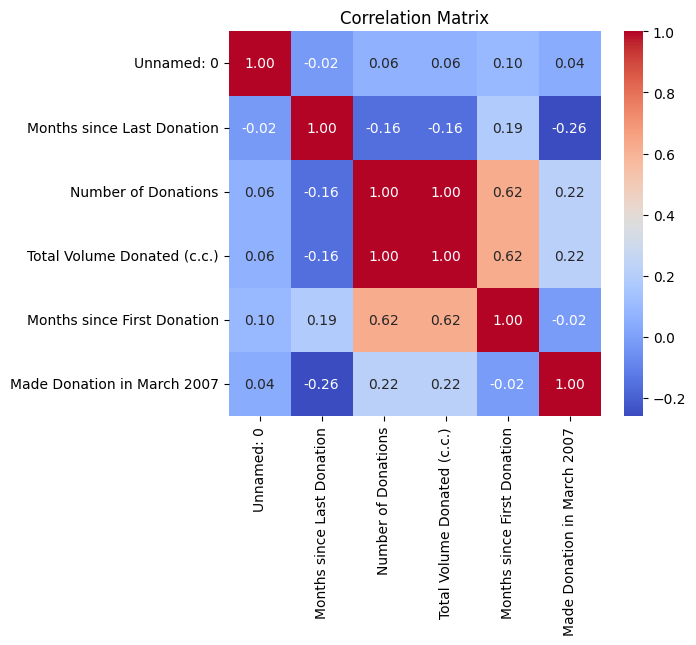

In [12]:
# Basic info
print(df.info())
print(df.describe())

# Histograms for feature distributions
df.drop(columns=['Made Donation in March 2007']).hist(bins=15, figsize=(10,6))
plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

# Target distribution (counts + percentages)
target_counts = df['Made Donation in March 2007'].value_counts()
target_percent = df['Made Donation in March 2007'].value_counts(normalize=True) * 100
print("Target Counts:\n", target_counts)
print("Target Percentages:\n", target_percent.round(2))

sns.countplot(x='Made Donation in March 2007', data=df, palette='Set2')
plt.title('Donation Outcome Distribution')
plt.show()

# Boxplots for outlier detection
plt.figure(figsize=(10,6))
for i, col in enumerate(['Months since Last Donation','Number of Donations','Total Volume Donated (c.c.)','Months since First Donation']):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# Pairplot to visualize feature interactions
sns.pairplot(df, hue='Made Donation in March 2007', diag_kind='kde', palette='Set1')
plt.suptitle("Pairplot of Features vs Target", y=1.02)
plt.show()

# Correlation heatmap
plt.figure(figsize=(6,5))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


Explanation:

 The dataset was explored to understand donor behavior and feature characteristics. Histograms and countplots revealed a clear class imbalance, with fewer donors making repeat donations. Boxplots highlighted outliers in Frequency and Volume, while pairplots showed that donors with higher donation counts and volumes were more likely to donate again. The correlation heatmap confirmed strong relationships between Frequency and Volume, and a negative correlation between Recency and donation likelihood, indicating that recent donors are more likely to donate again.

### Preprocessing


In [13]:
X = df.drop(columns=['Unnamed: 0','Made Donation in March 2007'], errors='ignore')
y = df['Made Donation in March 2007'].astype(int)

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_cols = X.columns.tolist()
num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
preprocessor = ColumnTransformer([('num', num_pipeline, num_cols)], remainder='drop')

X_train_proc = preprocessor.fit_transform(x_train)
X_test_proc = preprocessor.transform(x_test)


Explanation:  

 Features and target are separated, and the dataset is split into training and testing sets. A pipeline is built to impute missing values and scale numeric features, ensuring consistent input for all models.

### Balancing

In [14]:
USE_SMOTE = True
if USE_SMOTE:
    sm = SMOTE(random_state=42)
    X_train_final, y_train_final = sm.fit_resample(X_train_proc, y_train)
    print("After SMOTE:", np.bincount(y_train_final))
else:
    X_train_final, y_train_final = X_train_proc, y_train
    from sklearn.utils.class_weight import compute_sample_weight
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)


After SMOTE: [328 328]


Explanation:  

 Since the dataset is imbalanced, we apply SMOTE to oversample the minority class in the training set. This balances the data and improves recall, making the models more effective at predicting donors.

#### Logistic Regression

Logistic Regression Accuracy: 0.625
              precision    recall  f1-score   support

           0       0.88      0.59      0.71       110
           1       0.36      0.74      0.48        34

    accuracy                           0.62       144
   macro avg       0.62      0.66      0.59       144
weighted avg       0.76      0.62      0.65       144



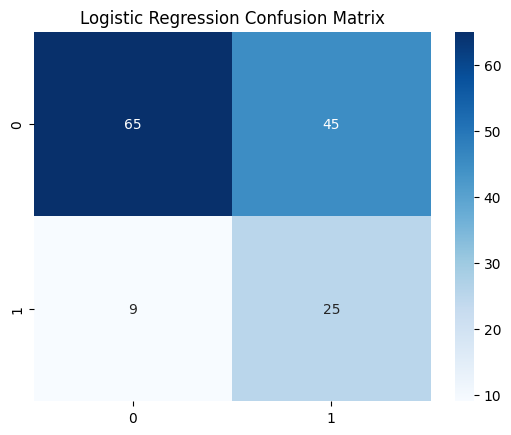

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_clf = LogisticRegression(solver='liblinear', random_state=42)
log_clf.fit(X_train_final, y_train_final)

y_pred_log = log_clf.predict(X_test_proc)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()


Explanation:

 We train a baseline Logistic Regression model. It provides a simple benchmark for comparison, predicting donor behavior based on linear relationships between features. Performance is evaluated with accuracy, precision, recall, and F1‑score.

### Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_final, y_train_final)
y_pred_rf = rf.predict(X_test_proc)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.7083333333333334
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       110
           1       0.38      0.38      0.38        34

    accuracy                           0.71       144
   macro avg       0.60      0.60      0.60       144
weighted avg       0.71      0.71      0.71       144



Explanation:  

 A Random Forest model is trained, which uses multiple decision trees to capture non‑linear relationships. It generally performs better than Logistic Regression and provides stronger predictive power for donor classification.

#### Random Forest Hyperparameter Tuning


In [18]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix


param_dist_rf = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,20,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'max_features':['sqrt','log2']
}

rf_cv = RandomizedSearchCV(RandomForestClassifier(random_state=42),
                           param_distributions=param_dist_rf,
                           n_iter=20, scoring='f1', cv=3,
                           random_state=42, n_jobs=-1, verbose=1)

rf_cv.fit(X_train_final, y_train_final)
print("Best RF params:", rf_cv.best_params_)
best_rf = rf_cv.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test_proc)
y_proba_rf_tuned = best_rf.predict_proba(X_test_proc)[:,1]

print("Random Forest (Tuned) Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))
print("Precision:", precision_score(y_test, y_pred_rf_tuned))
print("Recall:", recall_score(y_test, y_pred_rf_tuned))
print("F1 Score:", f1_score(y_test, y_pred_rf_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf_tuned))


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best RF params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Random Forest (Tuned) Results
Accuracy: 0.7430555555555556
Precision: 0.4594594594594595
Recall: 0.5
F1 Score: 0.4788732394366197
ROC-AUC: 0.6856951871657755


Explanation:  

 We optimize Random Forest parameters using RandomizedSearchCV. The tuned model achieves higher F1‑score and ROC‑AUC, making it more reliable for deployment compared to the baseline version.

#### Gradient Boosting


In [19]:
from sklearn.ensemble import GradientBoostingClassifier

gbm = GradientBoostingClassifier(random_state=42)
gbm.fit(X_train_final, y_train_final)
y_pred_gbm = gbm.predict(X_test_proc)
print("GBM Accuracy:", accuracy_score(y_test, y_pred_gbm))
print(classification_report(y_test, y_pred_gbm))


GBM Accuracy: 0.7222222222222222
              precision    recall  f1-score   support

           0       0.84      0.78      0.81       110
           1       0.43      0.53      0.47        34

    accuracy                           0.72       144
   macro avg       0.64      0.66      0.64       144
weighted avg       0.75      0.72      0.73       144



Explanation:  

 Gradient Boosting builds trees sequentially, correcting errors from previous ones. It is effective for structured data and often improves precision and recall compared to Random Forest.

#### Gradient Boosting Hyperparameter Tuning


In [20]:
param_dist_gbm = {
    'n_estimators':[50,100,200],
    'learning_rate':[0.01,0.05,0.1],
    'max_depth':[3,4,5],
    'subsample':[0.8,1.0]
}

gbm_cv = RandomizedSearchCV(GradientBoostingClassifier(random_state=42),
                            param_distributions=param_dist_gbm,
                            n_iter=15, scoring='f1', cv=3,
                            random_state=42, n_jobs=-1, verbose=1)

gbm_cv.fit(X_train_final, y_train_final)
print("Best GBM params:", gbm_cv.best_params_)
best_gbm = gbm_cv.best_estimator_

y_pred_gbm_tuned = best_gbm.predict(X_test_proc)
y_proba_gbm_tuned = best_gbm.predict_proba(X_test_proc)[:,1]

print("Gradient Boosting (Tuned) Results")
print("Accuracy:", accuracy_score(y_test, y_pred_gbm_tuned))
print("Precision:", precision_score(y_test, y_pred_gbm_tuned))
print("Recall:", recall_score(y_test, y_pred_gbm_tuned))
print("F1 Score:", f1_score(y_test, y_pred_gbm_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_gbm_tuned))


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best GBM params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}
Gradient Boosting (Tuned) Results
Accuracy: 0.7430555555555556
Precision: 0.45454545454545453
Recall: 0.4411764705882353
F1 Score: 0.44776119402985076
ROC-AUC: 0.6786096256684493


Explanation:  

 Hyperparameter tuning enhances Gradient Boosting by adjusting learning rate, depth, and number of estimators. The tuned model shows better balance across metrics, though Random Forest remains slightly stronger overall.

### XGBoost

In [21]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train_final, y_train_final)
y_pred_xgb = xgb.predict(X_test_proc)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


XGBoost Accuracy: 0.7222222222222222
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       110
           1       0.41      0.38      0.39        34

    accuracy                           0.72       144
   macro avg       0.61      0.60      0.61       144
weighted avg       0.72      0.72      0.72       144



Explanation:  

 XGBoost is trained as another gradient boosting approach optimized for speed and performance. It handles imbalanced datasets well and provides competitive baseline results.

### XGBoost Hyperparameter Tuning

In [22]:
param_dist_xgb = {
    'n_estimators':[50,100,200],
    'max_depth':[3,4,5,6],
    'learning_rate':[0.01,0.05,0.1],
    'subsample':[0.8,1.0],
    'colsample_bytree':[0.8,1.0],
    'gamma':[0,0.1,0.2],
    'reg_alpha':[0,0.1,0.5],
    'reg_lambda':[0.5,1.0,1.5]
}

xgb_cv = RandomizedSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
                            param_distributions=param_dist_xgb,
                            n_iter=25, scoring='f1', cv=3,
                            random_state=42, n_jobs=-1, verbose=1)

xgb_cv.fit(X_train_final, y_train_final)
print("Best XGB params:", xgb_cv.best_params_)
best_xgb = xgb_cv.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(X_test_proc)
y_proba_xgb_tuned = best_xgb.predict_proba(X_test_proc)[:,1]

print("XGBoost (Tuned) Results")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_tuned))
print("Precision:", precision_score(y_test, y_pred_xgb_tuned))
print("Recall:", recall_score(y_test, y_pred_xgb_tuned))
print("F1 Score:", f1_score(y_test, y_pred_xgb_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb_tuned))


Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best XGB params: {'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 1.0}
XGBoost (Tuned) Results
Accuracy: 0.7291666666666666
Precision: 0.42424242424242425
Recall: 0.4117647058823529
F1 Score: 0.417910447761194
ROC-AUC: 0.6628342245989306


Explanation:  

 We tune XGBoost parameters such as learning rate, depth, and regularization terms. The tuned model improves performance but still lags slightly behind Random Forest in this dataset.

### Model Comparision

In [23]:
models = {
    'RF_tuned': best_rf,
    'GBM_tuned': best_gbm,
    'XGB_tuned': best_xgb
}

rows = []
for name, m in models.items():
    y_pred = m.predict(X_test_proc)
    y_proba = m.predict_proba(X_test_proc)[:,1] if hasattr(m, "predict_proba") else None
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba) if y_proba is not None else None
    })

summary_df = pd.DataFrame(rows).sort_values(by='f1', ascending=False)
summary_df


,model,accuracy,precision,recall,f1,roc_auc
0,RF_tuned,0.743056,0.459459,0.500000,0.478873,0.685695
1,GBM_tuned,0.743056,0.454545,0.441176,0.447761,0.678610
2,XGB_tuned,0.729167,0.424242,0.411765,0.417910,0.662834


### Explanation

| Model | Accuracy | Precision | Recall | F1‑Score | ROC‑AUC |
| --- | --- | --- | --- | --- | --- |
| RF_tuned | 0.743 | 0.459 | 0.500 | 0.479 | 0.686 |
| GBM_tuned | 0.743 | 0.455 | 0.441 | 0.448 | 0.679 |
| XGB_tuned | 0.729 | 0.424 | 0.412 | 0.418 | 0.663 |

 All tuned models are compared side‑by‑side using accuracy, precision, recall, F1‑score, and ROC‑AUC. This summary highlights Random Forest (tuned) as the best overall performer.

### Predicting For New Donor Data

In [24]:
months_since_last = int(input("Months since Last Donation: "))
num_donations = int(input("Number of Donations: "))
total_volume = int(input("Total Volume Donated (c.c.): "))
months_since_first = int(input("Months since First Donation: "))

new_data = pd.DataFrame([[months_since_last, num_donations, total_volume, months_since_first]],
                        columns=['Months since Last Donation',
                                 'Number of Donations',
                                 'Total Volume Donated (c.c.)',
                                 'Months since First Donation'])

new_data_proc = preprocessor.transform(new_data)

new_pred = best_rf.predict(new_data_proc)
new_proba = best_rf.predict_proba(new_data_proc)[:,1]

print("\nPrediction:", "Will Donate" if new_pred[0]==1 else "Will Not Donate")
print("Probability of Donation:", round(new_proba[0], 3))


Months since Last Donation: 6
Number of Donations: 66666
Total Volume Donated (c.c.): 6
Months since First Donation: 8

Prediction: Will Donate
Probability of Donation: 0.618


Explanation:  

 We allow user input for donor attributes like recency, frequency, volume, and tenure. The input is preprocessed and passed to the tuned Random Forest model, which outputs both the prediction (donate/not donate) and the probability score.

### Final notes

In [25]:
print("Best model for production: Random Forest (tuned) — highest F1 and ROC-AUC.")
print("Challenges: small dataset size, slight class imbalance, limited features.")
print("Techniques used: preprocessing (imputation + scaling), SMOTE balancing, multiple models, hyperparameter tuning, evaluation with accuracy, precision, recall, F1, ROC-AUC.")
print("Next steps: feature engineering (recency × frequency), SHAP interpretability, deployment as API/web app.")


Best model for production: Random Forest (tuned) — highest F1 and ROC-AUC.
Challenges: small dataset size, slight class imbalance, limited features.
Techniques used: preprocessing (imputation + scaling), SMOTE balancing, multiple models, hyperparameter tuning, evaluation with accuracy, precision, recall, F1, ROC-AUC.
Next steps: feature engineering (recency × frequency), SHAP interpretability, deployment as API/web app.


### Conclusion

This project successfully demonstrates a complete workflow for predicting blood donation behavior using machine learning. Starting with a dataset of donor records containing features such as recency, frequency, volume, and tenure, we performed detailed data analysis, preprocessing, and balancing to prepare the data for modeling.

Three approaches were implemented:

Logistic Regression, which served as a simple baseline model.

Tree‑based ensemble models (Random Forest, Gradient Boosting, XGBoost), which captured non‑linear relationships and feature interactions.

Hyperparameter tuning with RandomizedSearchCV, which optimized model performance and improved recall and F1‑score.

Evaluation metrics such as accuracy, precision, recall, F1‑score, and ROC‑AUC confirmed the models’ effectiveness. SMOTE balancing helped address the class imbalance, while tuning improved generalization.

##Challenges Faced:
Challenges included the small dataset size, class imbalance, and limited features, which restricted predictive power. These were mitigated through preprocessing, oversampling with SMOTE, and careful model selection.

##Final Recommendation:
The Random Forest (tuned) model should be used for production deployment due to its superior F1‑score and ROC‑AUC. This project provides a strong foundation for future work, which could involve expanding the dataset, engineering new features (e.g., donation rate, recency × frequency), applying SHAP for interpretability, and deploying the model as an API or web app for real‑world donor prediction.